<a href="https://colab.research.google.com/github/a4kashhh/Graph-Neural-Network/blob/main/GNN_Explanation_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git
!pip install -q captum
%matplotlib inline
import matplotlib.pyplot as plt

2.11.0+cpu
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import TUDataset

path = '.'
dataset = TUDataset(path, name='Mutagenicity').shuffle()
test_dataset = dataset[:len(dataset) // 10]
train_dataset = dataset[len(dataset) // 10:]
test_loader = DataLoader(test_dataset, batch_size=128)
train_loader = DataLoader(train_dataset, batch_size=128)

In [17]:
import networkx as nx
import numpy as np

from torch_geometric.utils import to_networkx


def draw_molecule(g, edge_mask=None, draw_edge_labels=False):
    g = g.copy().to_undirected()
    node_labels = {}
    for u, data in g.nodes(data=True):
        node_labels[u] = data['name']
    pos = nx.planar_layout(g)
    pos = nx.spring_layout(g, pos=pos)
    if edge_mask is None:
        edge_color = 'black'
        widths = None
    else:
        edge_color = [edge_mask[(u, v)] for u, v in g.edges()]
        widths = [x * 10 for x in edge_color]
    nx.draw(g, pos=pos, labels=node_labels, width=widths,
            edge_color=edge_color, edge_cmap=plt.cm.Blues,
            node_color='azure')

    if draw_edge_labels and edge_mask is not None:
        edge_labels = {k: ('%.2f' % v) for k, v in edge_mask.items()}
        nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels,
                                    font_color='red')
    plt.show()


def to_molecule(data):
    ATOM_MAP = ['C', 'O', 'Cl', 'H', 'N', 'F',
                'Br', 'S', 'P', 'I', 'Na', 'K', 'Li', 'Ca']
    g = to_networkx(data, node_attrs=['x'])
    for u, data in g.nodes(data=True):
        data['name'] = ATOM_MAP[data['x'].index(1.0)]
        del data['x']
    return g


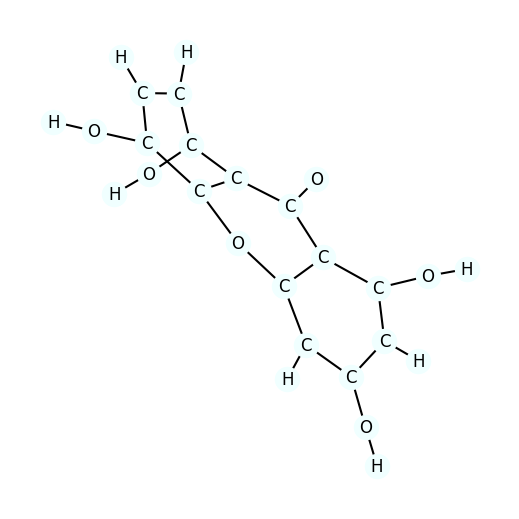

In [18]:
import random
data = random.choice([t for t in train_dataset])
mol = to_molecule(data)
plt.figure(figsize=(5,5))
draw_molecule(mol)

# **1,1-Dibromoethane**

In [22]:
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_add_pool
class Net(torch.nn.Module):
    def __init__(self, dim):
        super(Net, self).__init__()
        num_features = dataset.num_features
        self.dim = dim
        self.conv1 = GCNConv(num_features, dim)
        self.conv2 = GCNConv(dim, dim)
        self.conv3 = GCNConv(dim, dim)
        self.conv4 = GCNConv(dim, dim)
        self.conv5 = GCNConv(dim, dim)
        self.lin1 = Linear(dim, dim)
        self.lin2 = Linear(dim, dataset.num_classes)
    def forward(self, x, edge_index, batch, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight).relu()
        x = self.conv2(x, edge_index, edge_weight).relu()
        x = self.conv3(x, edge_index, edge_weight).relu()
        x = self.conv4(x, edge_index, edge_weight).relu()
        x = self.conv5(x, edge_index, edge_weight).relu()
        x = global_add_pool(x, batch)
        x = self.lin1(x).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

In [20]:
def train(epoch):
    model.train()

    if epoch == 51:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.5 * param_group['lr']

    loss_all = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data.x, data.edge_index, data.batch)
        loss = F.nll_loss(output, data.y)
        loss.backward()
        loss_all += loss.item() * data.num_graphs
        optimizer.step()
    return loss_all / len(train_dataset)


def test(loader):
    model.eval()

    correct = 0
    for data in loader:
        data = data.to(device)
        output = model(data.x, data.edge_index, data.batch)
        pred = output.max(dim=1)[1]
        correct += pred.eq(data.y).sum().item()
    return correct / len(loader.dataset)

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net(dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 101):
    loss = train(epoch)
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, '
          f'Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Loss: 0.6640, Train Acc: 0.6411, Test Acc: 0.6282
Epoch: 002, Loss: 0.6269, Train Acc: 0.6555, Test Acc: 0.6328
Epoch: 003, Loss: 0.6126, Train Acc: 0.6724, Test Acc: 0.6513
Epoch: 004, Loss: 0.6046, Train Acc: 0.6709, Test Acc: 0.6397
Epoch: 005, Loss: 0.5952, Train Acc: 0.6929, Test Acc: 0.6536
Epoch: 006, Loss: 0.5830, Train Acc: 0.7139, Test Acc: 0.6836
Epoch: 007, Loss: 0.5748, Train Acc: 0.7185, Test Acc: 0.6905
Epoch: 008, Loss: 0.5604, Train Acc: 0.7421, Test Acc: 0.6836
Epoch: 009, Loss: 0.5693, Train Acc: 0.7029, Test Acc: 0.6605
Epoch: 010, Loss: 0.5569, Train Acc: 0.7203, Test Acc: 0.6905
Epoch: 011, Loss: 0.5555, Train Acc: 0.7382, Test Acc: 0.6952
Epoch: 012, Loss: 0.5525, Train Acc: 0.7303, Test Acc: 0.6813
Epoch: 013, Loss: 0.5492, Train Acc: 0.7211, Test Acc: 0.6767
Epoch: 014, Loss: 0.5421, Train Acc: 0.7485, Test Acc: 0.6952
Epoch: 015, Loss: 0.5401, Train Acc: 0.7520, Test Acc: 0.6998
Epoch: 016, Loss: 0.5400, Train Acc: 0.7387, Test Acc: 0.7044
Epoch: 0

In [24]:
from captum.attr import Saliency, IntegratedGradients
def model_forward(edge_mask, data):
    batch = torch.zeros(data.x.shape[0], dtype=int).to(device)
    out = model(data.x, data.edge_index, batch, edge_mask)
    return out
def explain(method, data, target=0):
    input_mask = torch.ones(data.edge_index.shape[1]).requires_grad_(True).to(device)
    if method == 'ig':
        ig = IntegratedGradients(model_forward)
        mask = ig.attribute(input_mask, target=target, additional_forward_args=(data,), internal_batch_size=data.edge_index.shape[1])
    elif method == 'saliency':
        saliency = Saliency(model_forward)
        mask = saliency.attribute(input_mask, target=target, additional_forward_args=(data,))
    else: raise Exception('Unknown explanation method')
    edge_mask = np.abs(mask.cpu().detach().numpy())
    if edge_mask.max() > 0:  # avoid division by zero
        edge_mask = edge_mask / edge_mask.max()
    return edge_mask

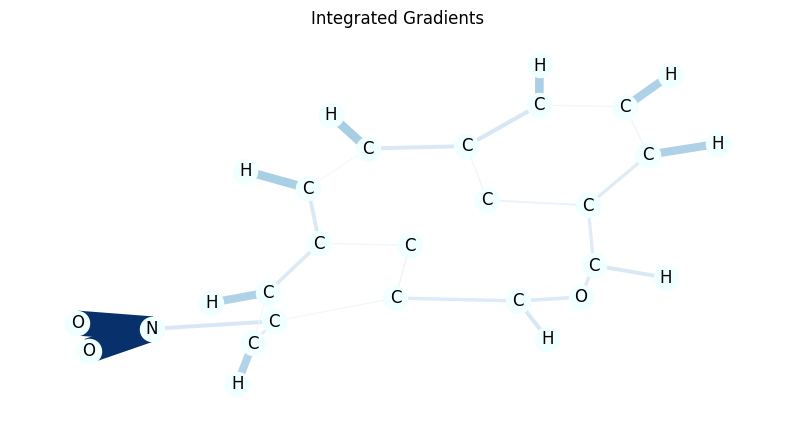

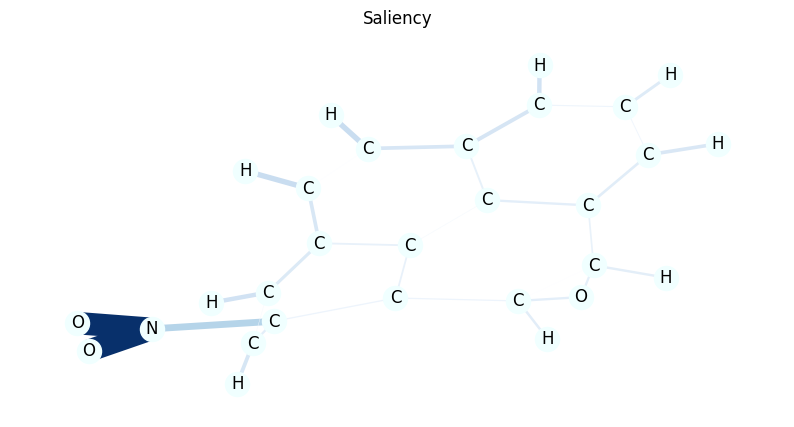

In [25]:
import random
from collections import defaultdict
def aggregate_edge_directions(edge_mask, data):
    edge_mask_dict = defaultdict(float)
    for val, u, v in list(zip(edge_mask, *data.edge_index)):
        u, v = u.item(), v.item()
        if u > v:
            u, v = v, u
        edge_mask_dict[(u, v)] += val
    return edge_mask_dict
data = random.choice([t for t in test_dataset if not t.y.item()])
mol = to_molecule(data)
for title, method in [('Integrated Gradients', 'ig'), ('Saliency', 'saliency')]:
    edge_mask = explain(method, data, target=0)
    edge_mask_dict = aggregate_edge_directions(edge_mask, data)
    plt.figure(figsize=(10, 5))
    plt.title(title)
    draw_molecule(mol, edge_mask_dict)